In [1]:
# Importar librerías
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# Configuración de la API
API_KEY = "CG-DwAqwF45AgPp9npouBntNF5M"  # Reemplaza con tu key real

headers = {
    "accept": "application/json",
    "x-cg-demo-api-key": API_KEY
}

print("✅ API configurada correctamente")

✅ API configurada correctamente


In [3]:
# Verificar conexión a la API
url = "https://api.coingecko.com/api/v3/ping"
response = requests.get(url, headers=headers)

print(f"Status: {response.status_code}")
print(response.json())

Status: 200
{'gecko_says': '(V3) To the Moon!'}


In [4]:
# Extraer top 50 criptomonedas por capitalización de mercado
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,
    "page": 1,
    "sparkline": False
}

response = requests.get(url, headers=headers, params=params)
data = response.json()

print(f"✅ {len(data)} criptomonedas extraídas")
print(f"Primera cripto: {data[0]['name']} - ${data[0]['current_price']:,.2f}")

✅ 50 criptomonedas extraídas
Primera cripto: Bitcoin - $78,500.00


In [5]:
# Convertir a DataFrame y seleccionar columnas relevantes
df = pd.DataFrame(data)

df = df[[
    'name',
    'symbol',
    'current_price',
    'market_cap',
    'total_volume',
    'price_change_percentage_24h',
    'high_24h',
    'low_24h',
    'circulating_supply'
]]

# Renombrar columnas al español
df.columns = [
    'nombre',
    'simbolo',
    'precio_usd',
    'capitalizacion_mercado',
    'volumen_24h',
    'variacion_24h_pct',
    'maximo_24h',
    'minimo_24h',
    'suministro_circulante'
]

print(df.head())
print(f"\nDimensiones: {df.shape}")

     nombre simbolo    precio_usd  capitalizacion_mercado   volumen_24h  \
0   Bitcoin     btc  78500.000000           1571945628221  3.834424e+10   
1  Ethereum     eth   2306.870000            278388729470  1.045639e+10   
2    Tether    usdt      0.999795            189536721301  5.762942e+10   
3       XRP     xrp      1.400000             86012608260  1.685026e+09   
4       BNB     bnb    619.830000             83496902188  8.038268e+08   

   variacion_24h_pct    maximo_24h    minimo_24h  suministro_circulante  
0            2.80241  78773.000000  76189.000000           2.002327e+07  
1            2.05703   2322.350000   2252.420000           1.206876e+08  
2            0.00909      0.999846      0.999447           1.895745e+11  
3            1.73897      1.400000      1.360000           6.168578e+10  
4            0.37396    622.360000    614.650000           1.347861e+08  

Dimensiones: (50, 9)


In [6]:
# Extraer historial de precios de Bitcoin últimos 30 días
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": 30,
    "interval": "daily"
}

response = requests.get(url, headers=headers, params=params)
btc_data = response.json()

# Convertir a DataFrame
btc_df = pd.DataFrame(btc_data['prices'], columns=['timestamp', 'precio_usd'])

# Convertir timestamp a fecha legible
btc_df['fecha'] = pd.to_datetime(btc_df['timestamp'], unit='ms')
btc_df = btc_df[['fecha', 'precio_usd']]

print(f"✅ {len(btc_df)} días de historial de Bitcoin")
print(btc_df.head())

✅ 31 días de historial de Bitcoin
       fecha    precio_usd
0 2026-04-02  68089.055382
1 2026-04-03  66891.664569
2 2026-04-04  66939.691217
3 2026-04-05  67304.249556
4 2026-04-06  68985.526427


In [7]:
# Extraer historial de precios de Ethereum últimos 30 días
url = "https://api.coingecko.com/api/v3/coins/ethereum/market_chart"

params = {
    "vs_currency": "usd",
    "days": 30,
    "interval": "daily"
}

response = requests.get(url, headers=headers, params=params)
eth_data = response.json()

# Convertir a DataFrame
eth_df = pd.DataFrame(eth_data['prices'], columns=['timestamp', 'precio_usd'])
eth_df['fecha'] = pd.to_datetime(eth_df['timestamp'], unit='ms')
eth_df = eth_df[['fecha', 'precio_usd']]

print(f"✅ {len(eth_df)} días de historial de Ethereum")
print(eth_df.head())

✅ 31 días de historial de Ethereum
       fecha   precio_usd
0 2026-04-02  2139.057889
1 2026-04-03  2056.890296
2 2026-04-04  2053.608815
3 2026-04-05  2064.994058
4 2026-04-06  2109.005556


In [8]:
# Revisar nulos en el DataFrame principal
print("=== REVISIÓN DE CALIDAD DE DATOS ===")
print(f"\nNulos por columna:")
print(df.isnull().sum())
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nEstadísticas básicas:")
print(df[['precio_usd', 'variacion_24h_pct', 'capitalizacion_mercado']].describe())

=== REVISIÓN DE CALIDAD DE DATOS ===

Nulos por columna:
nombre                    0
simbolo                   0
precio_usd                0
capitalizacion_mercado    0
volumen_24h               0
variacion_24h_pct         1
maximo_24h                1
minimo_24h                1
suministro_circulante     0
dtype: int64

Tipos de datos:
nombre                        str
simbolo                       str
precio_usd                float64
capitalizacion_mercado      int64
volumen_24h               float64
variacion_24h_pct         float64
maximo_24h                float64
minimo_24h                float64
suministro_circulante     float64
dtype: object

Estadísticas básicas:
         precio_usd  variacion_24h_pct  capitalizacion_mercado
count     50.000000          49.000000            5.000000e+01
mean    1850.219851           0.876473            5.152725e+10
std    11102.399305           2.788325            2.248361e+11
min        0.000004          -9.430330            1.676654e+09
25%

In [9]:
# Rellenar nulos si los hay
df = df.fillna(0)

# Agregar columna de ranking
df['ranking'] = range(1, len(df) + 1)

# Agregar columna de capitalización en billones
df['cap_billones_usd'] = df['capitalizacion_mercado'] / 1_000_000_000

# Agregar columna de señal — sube o baja
df['tendencia'] = df['variacion_24h_pct'].apply(
    lambda x: '🟢 Sube' if x > 0 else '🔴 Baja'
)

print("✅ Datos enriquecidos correctamente")
print(df[['nombre', 'precio_usd', 'variacion_24h_pct', 'tendencia']].head(10))

✅ Datos enriquecidos correctamente
         nombre    precio_usd  variacion_24h_pct tendencia
0       Bitcoin  78500.000000            2.80241    🟢 Sube
1      Ethereum   2306.870000            2.05703    🟢 Sube
2        Tether      0.999795            0.00909    🟢 Sube
3           XRP      1.400000            1.73897    🟢 Sube
4           BNB    619.830000            0.37396    🟢 Sube
5          USDC      0.999755            0.00378    🟢 Sube
6        Solana     84.010000            1.11491    🟢 Sube
7          TRON      0.326537            0.03733    🟢 Sube
8  Figure Heloc      1.034000           -0.02838    🔴 Baja
9      Dogecoin      0.108966            3.16751    🟢 Sube


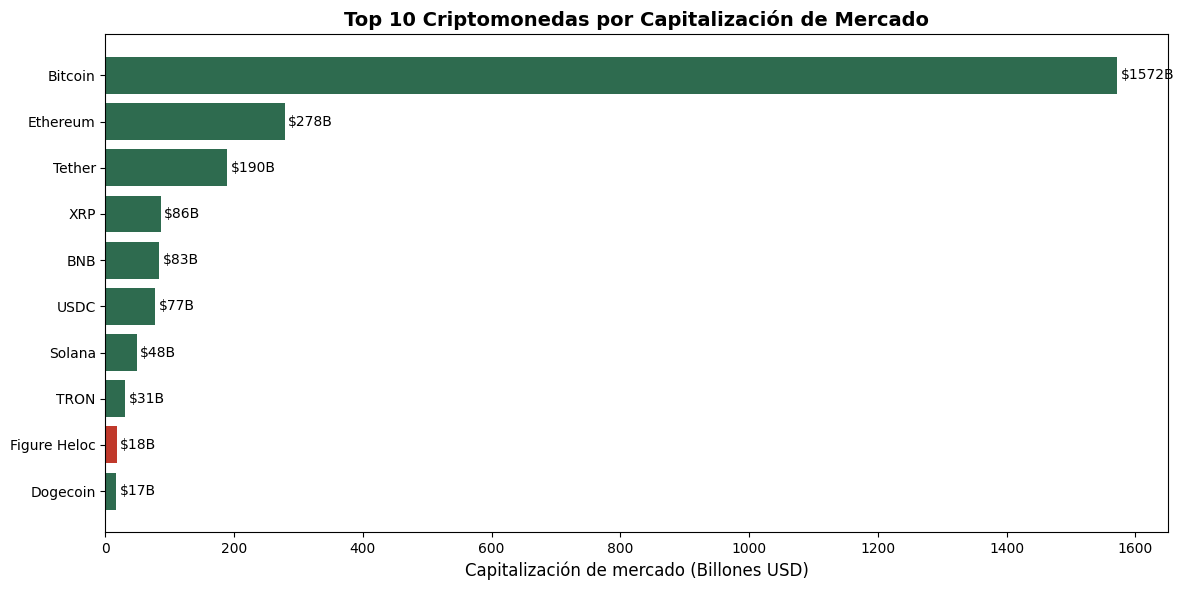

✅ Gráfica guardada


In [10]:
# Top 10 criptos por capitalización de mercado
fig, ax = plt.subplots(figsize=(12, 6))

top10 = df.head(10)
colores = ['#2E6B4F' if x > 0 else '#C0392B' 
           for x in top10['variacion_24h_pct']]

bars = ax.barh(top10['nombre'], top10['cap_billones_usd'], color=colores)

ax.set_xlabel('Capitalización de mercado (Billones USD)', fontsize=12)
ax.set_title('Top 10 Criptomonedas por Capitalización de Mercado', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Agregar valores
for bar, val in zip(bars, top10['cap_billones_usd']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}B', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../imagenes/top10_capitalizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")

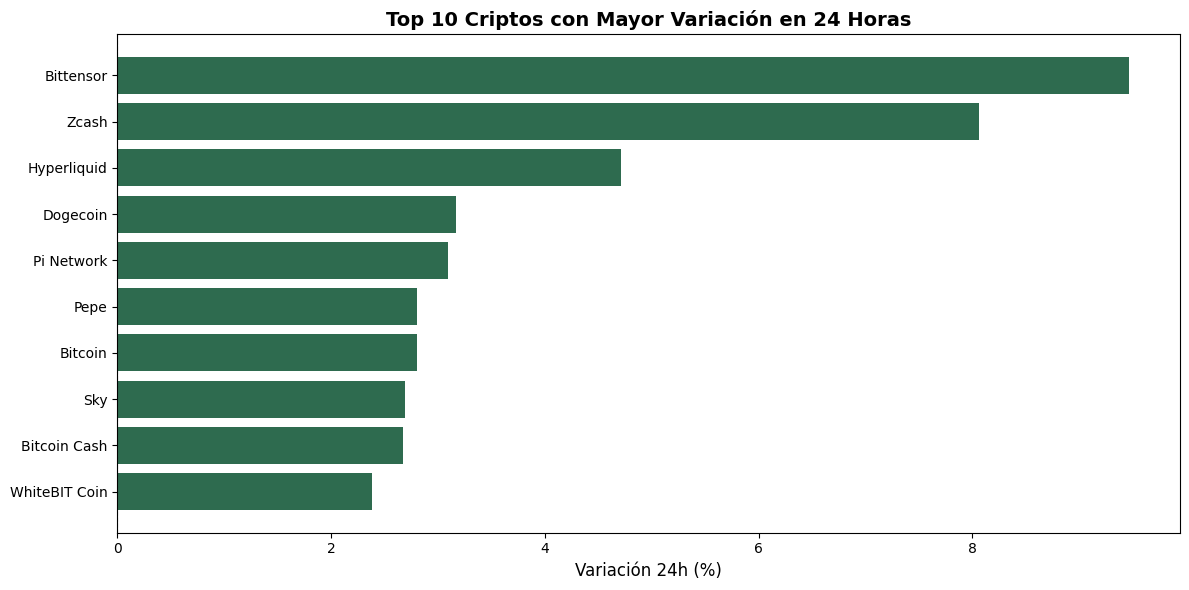

✅ Gráfica guardada


In [11]:
# Top 10 mayor variación en 24 horas
fig, ax = plt.subplots(figsize=(12, 6))

top_variacion = df.nlargest(10, 'variacion_24h_pct')
colores = ['#2E6B4F' if x > 0 else '#C0392B' 
           for x in top_variacion['variacion_24h_pct']]

bars = ax.barh(top_variacion['nombre'], 
               top_variacion['variacion_24h_pct'], color=colores)

ax.set_xlabel('Variación 24h (%)', fontsize=12)
ax.set_title('Top 10 Criptos con Mayor Variación en 24 Horas', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../imagenes/top10_variacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")

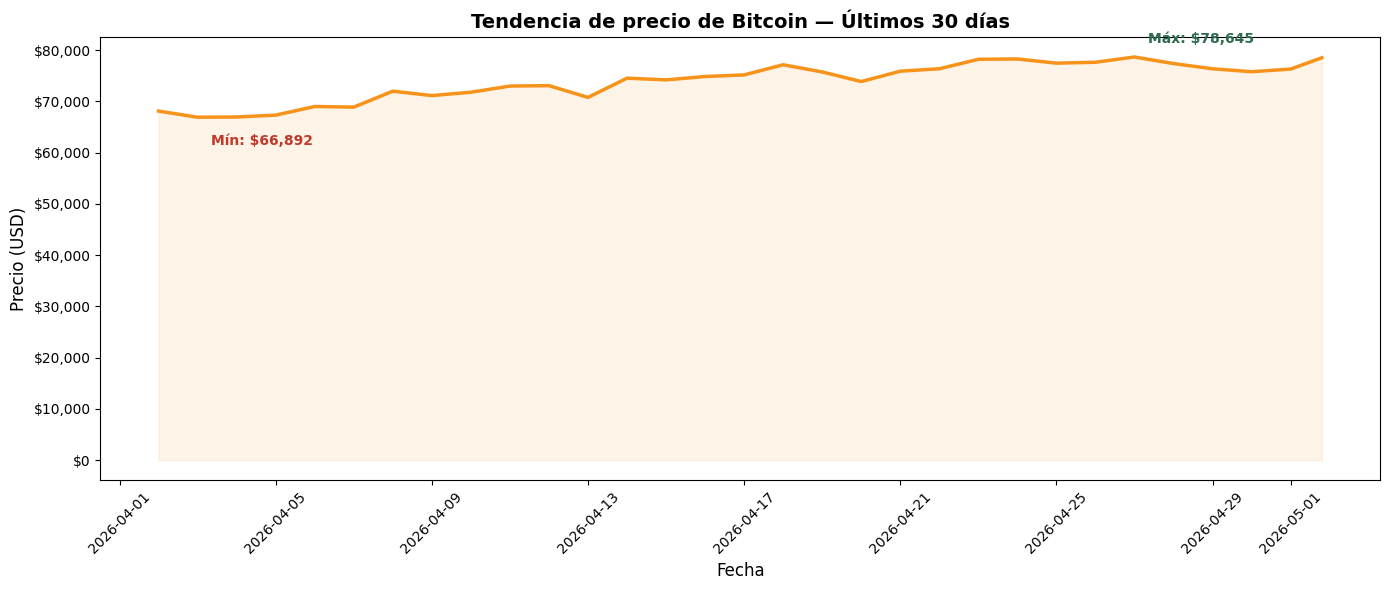

✅ Gráfica guardada


In [12]:
# Gráfica de tendencia de Bitcoin
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(btc_df['fecha'], btc_df['precio_usd'], 
        color='#F7931A', linewidth=2.5, label='Bitcoin')
ax.fill_between(btc_df['fecha'], btc_df['precio_usd'], 
                alpha=0.1, color='#F7931A')

# Marcar precio máximo y mínimo
max_idx = btc_df['precio_usd'].idxmax()
min_idx = btc_df['precio_usd'].idxmin()

ax.annotate(f"Máx: ${btc_df['precio_usd'].max():,.0f}",
            xy=(btc_df['fecha'][max_idx], btc_df['precio_usd'][max_idx]),
            xytext=(10, 10), textcoords='offset points',
            color='#2E6B4F', fontweight='bold')

ax.annotate(f"Mín: ${btc_df['precio_usd'].min():,.0f}",
            xy=(btc_df['fecha'][min_idx], btc_df['precio_usd'][min_idx]),
            xytext=(10, -20), textcoords='offset points',
            color='#C0392B', fontweight='bold')

ax.set_title('Tendencia de precio de Bitcoin — Últimos 30 días', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Precio (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../imagenes/bitcoin_tendencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")

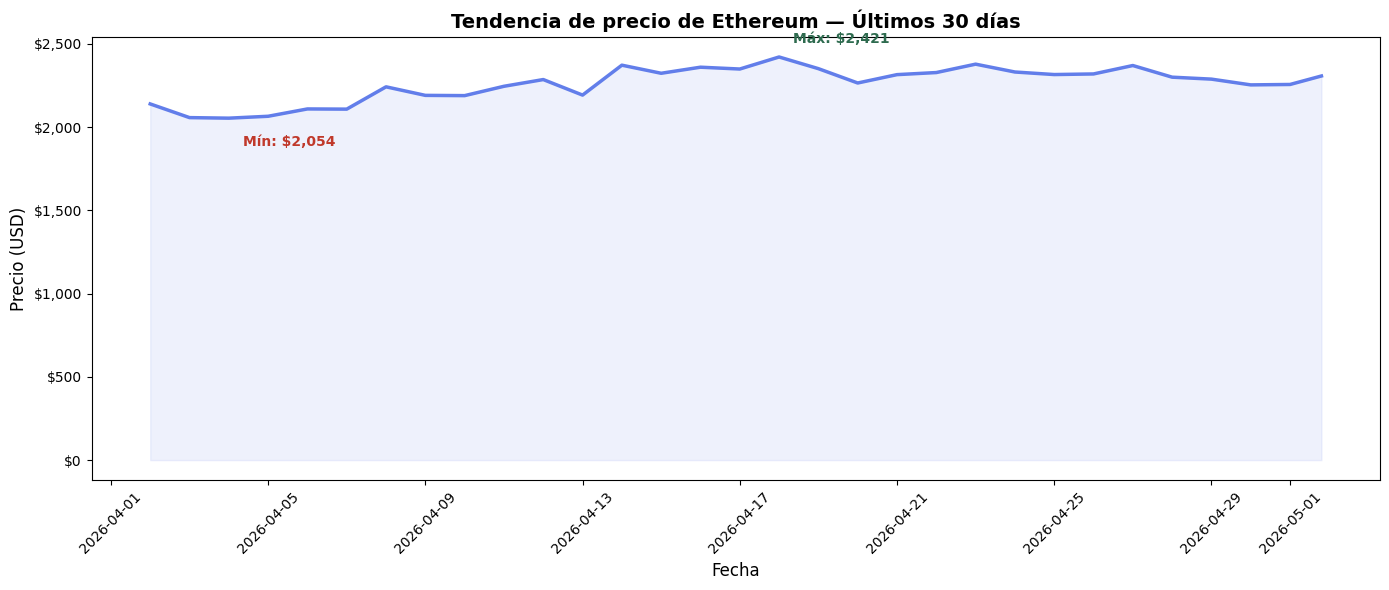

✅ Gráfica guardada


In [13]:
# Gráfica de tendencia de Ethereum
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(eth_df['fecha'], eth_df['precio_usd'], 
        color='#627EEA', linewidth=2.5, label='Ethereum')
ax.fill_between(eth_df['fecha'], eth_df['precio_usd'], 
                alpha=0.1, color='#627EEA')

max_idx = eth_df['precio_usd'].idxmax()
min_idx = eth_df['precio_usd'].idxmin()

ax.annotate(f"Máx: ${eth_df['precio_usd'].max():,.0f}",
            xy=(eth_df['fecha'][max_idx], eth_df['precio_usd'][max_idx]),
            xytext=(10, 10), textcoords='offset points',
            color='#2E6B4F', fontweight='bold')

ax.annotate(f"Mín: ${eth_df['precio_usd'].min():,.0f}",
            xy=(eth_df['fecha'][min_idx], eth_df['precio_usd'][min_idx]),
            xytext=(10, -20), textcoords='offset points',
            color='#C0392B', fontweight='bold')

ax.set_title('Tendencia de precio de Ethereum — Últimos 30 días', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Precio (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../imagenes/ethereum_tendencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")

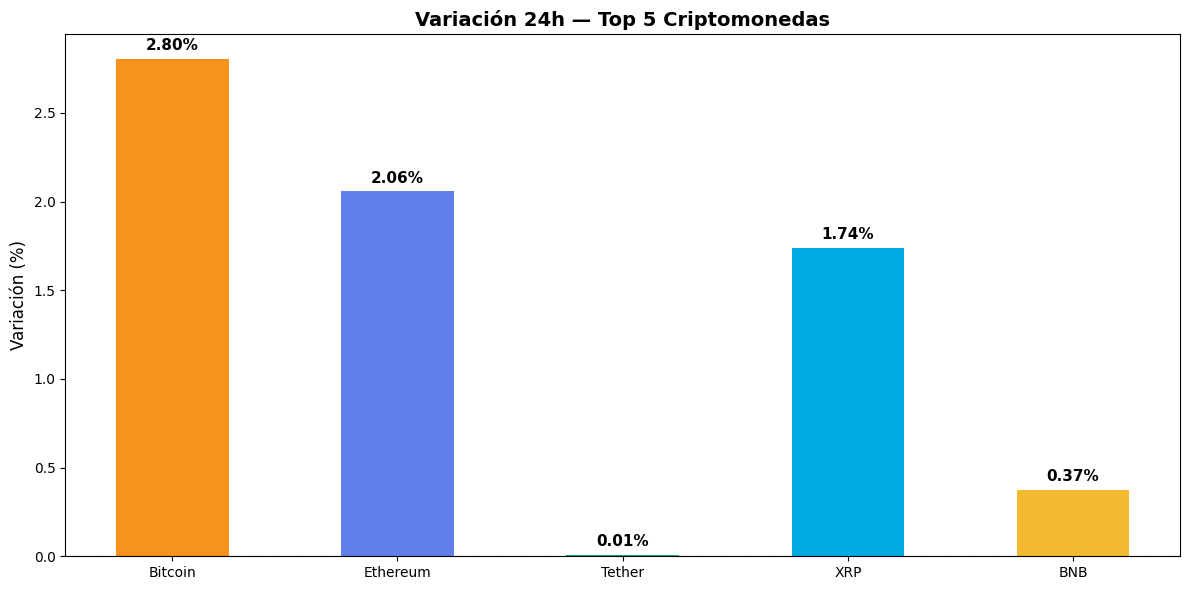

✅ Gráfica guardada


In [14]:
# Comparativa de rendimiento top 5 criptos
fig, ax = plt.subplots(figsize=(12, 6))

top5 = df.head(5)
colores = ['#F7931A', '#627EEA', '#26A17B', '#00AAE4', '#F3BA2F']

bars = ax.bar(top5['nombre'], top5['variacion_24h_pct'], 
              color=colores, width=0.5)

ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Variación 24h — Top 5 Criptomonedas', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Variación (%)', fontsize=12)

# Agregar valores encima de cada barra
for bar, val in zip(bars, top5['variacion_24h_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.15,
            f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../imagenes/top5_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")

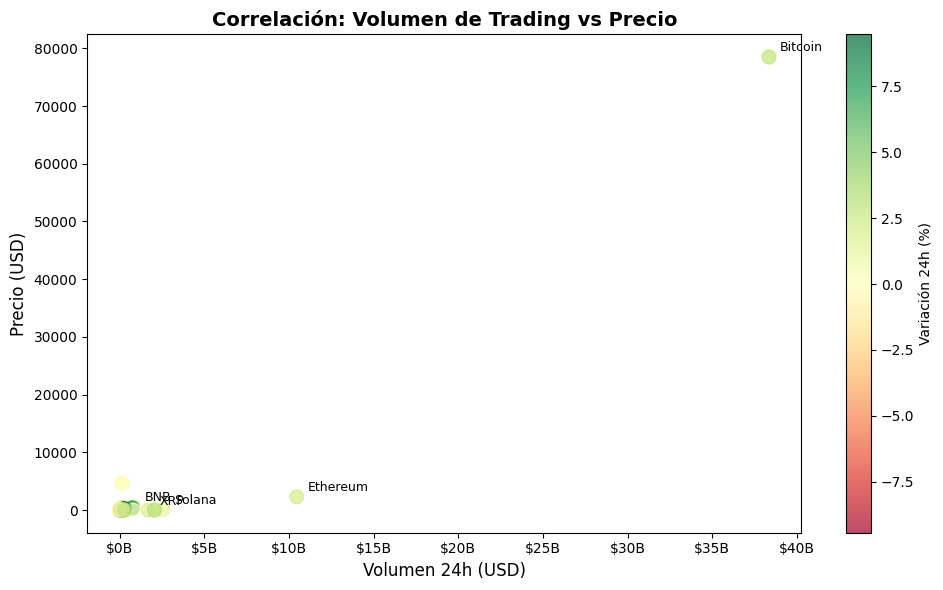

✅ Gráfica guardada


In [15]:
# Correlación entre volumen de trading y precio
fig, ax = plt.subplots(figsize=(10, 6))

# Excluir stablecoins para el análisis
no_stable = df[~df['nombre'].isin(['Tether', 'USDC', 'USDT', 'DAI'])]

scatter = ax.scatter(no_stable['volumen_24h'], 
                     no_stable['precio_usd'],
                     c=no_stable['variacion_24h_pct'],
                     cmap='RdYlGn',
                     s=100, alpha=0.7)

# Etiquetas para top 5
for _, row in no_stable.head(5).iterrows():
    ax.annotate(row['nombre'],
                (row['volumen_24h'], row['precio_usd']),
                textcoords='offset points',
                xytext=(8, 4), fontsize=9)

plt.colorbar(scatter, label='Variación 24h (%)')
ax.set_title('Correlación: Volumen de Trading vs Precio', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Volumen 24h (USD)', fontsize=12)
ax.set_ylabel('Precio (USD)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.0f}B'))
plt.tight_layout()
plt.savefig('../imagenes/correlacion_volumen_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")

In [16]:
# Corregir tipos de datos
btc_df['precio_usd'] = btc_df['precio_usd'].astype(float)
eth_df['precio_usd'] = eth_df['precio_usd'].astype(float)

# Verificar
print(btc_df.dtypes)
print(f"Precio actual BTC: ${btc_df['precio_usd'].iloc[-1]:,.2f}")

# Volver a exportar
btc_df.to_csv('../data/historial_bitcoin.csv', index=False)
eth_df.to_csv('../data/historial_ethereum.csv', index=False)
print("✅ CSVs corregidos y exportados")

fecha         datetime64[ms]
precio_usd           float64
dtype: object
Precio actual BTC: $78,491.36
✅ CSVs corregidos y exportados


In [17]:
# Resumen ejecutivo del análisis
print("=" * 50)
print("       RESUMEN EJECUTIVO — CRYPTO ANALYSIS")
print("=" * 50)
print(f"\n📅 Fecha del análisis: {datetime.now().strftime('%d/%m/%Y %H:%M')}")
print(f"\n📊 Dataset principal:")
print(f"   • Criptomonedas analizadas: {len(df)}")
print(f"   • Subiendo hoy: {len(df[df['variacion_24h_pct'] > 0])}")
print(f"   • Bajando hoy: {len(df[df['variacion_24h_pct'] < 0])}")
print(f"\n💰 Bitcoin (últimos 30 días):")
print(f"   • Precio actual: ${btc_df['precio_usd'].iloc[-1]:,.2f}")
print(f"   • Precio máximo: ${btc_df['precio_usd'].max():,.2f}")
print(f"   • Precio mínimo: ${btc_df['precio_usd'].min():,.2f}")
print(f"   • Variación total: {((btc_df['precio_usd'].iloc[-1] / btc_df['precio_usd'].iloc[0]) - 1) * 100:.2f}%")
print(f"\n💎 Ethereum (últimos 30 días):")
print(f"   • Precio actual: ${eth_df['precio_usd'].iloc[-1]:,.2f}")
print(f"   • Precio máximo: ${eth_df['precio_usd'].max():,.2f}")
print(f"   • Precio mínimo: ${eth_df['precio_usd'].min():,.2f}")
print(f"   • Variación total: {((eth_df['precio_usd'].iloc[-1] / eth_df['precio_usd'].iloc[0]) - 1) * 100:.2f}%")
print(f"\n🏆 Top 3 mejor rendimiento 24h:")
for _, row in df.nlargest(3, 'variacion_24h_pct').iterrows():
    print(f"   • {row['nombre']}: {row['variacion_24h_pct']:.2f}%")
print("=" * 50)

       RESUMEN EJECUTIVO — CRYPTO ANALYSIS

📅 Fecha del análisis: 01/05/2026 14:10

📊 Dataset principal:
   • Criptomonedas analizadas: 50
   • Subiendo hoy: 36
   • Bajando hoy: 12

💰 Bitcoin (últimos 30 días):
   • Precio actual: $78,491.36
   • Precio máximo: $78,645.13
   • Precio mínimo: $66,891.66
   • Variación total: 15.28%

💎 Ethereum (últimos 30 días):
   • Precio actual: $2,306.91
   • Precio máximo: $2,421.01
   • Precio mínimo: $2,053.61
   • Variación total: 7.85%

🏆 Top 3 mejor rendimiento 24h:
   • Bittensor: 9.47%
   • Zcash: 8.07%
   • Hyperliquid: 4.71%
